# Used Car Price Prediction

## Data Preparation and Preprocessing

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
data = pd.read_csv('/content/sample_data/car data.csv')

# View first 8 rows
data.head(8)

,car_name,brand,model,vehicle_age,km_driven,mileage,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,19.70,46.30,5,120000
1,Maruti Alto,Maruti,Alto,9,37000,20.92,67.10,5,226000
2,Maruti Wagon R,Maruti,Wagon R,8,35000,18.90,67.10,5,350000
3,Maruti Wagon R,Maruti,Wagon R,3,17512,20.51,67.04,5,410000
4,Hyundai Venue,Hyundai,Venue,2,20000,18.15,118.35,5,1050000
5,Maruti Alto,Maruti,Alto,8,25000,20.92,67.10,5,230000
6,Renault KWID,Renault,KWID,4,30000,23.01,67.00,5,340000
7,Maruti Wagon R,Maruti,Wagon R,2,10000,20.51,67.04,5,445000


# Understanding Data

In [3]:
data.shape

(2119, 9)

This dataset has 2119 samples (rows) and 9 columns

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_name       2119 non-null   object 
 1   brand          2119 non-null   object 
 2   model          2119 non-null   object 
 3   vehicle_age    2119 non-null   int64  
 4   km_driven      2119 non-null   int64  
 5   mileage        2119 non-null   float64
 6   max_power      2119 non-null   float64
 7   seats          2119 non-null   int64  
 8   selling_price  2119 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 149.1+ KB


From the above information, we observe that across the nine columns, there are no missing values in the dataset. Additionally, the car dataset consists of three data types: object (string), float64, and int64.

In [5]:
# Descriptive statistical analysis for both Numerical and Categorical columns
data.describe(include='all')

,car_name,brand,model,vehicle_age,km_driven,mileage,max_power,seats,selling_price
count,2119,2119,2119,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2.119000e+03
unique,13,6,13,NaN,NaN,NaN,NaN,NaN,NaN
top,Maruti Alto,Maruti,Alto,NaN,NaN,NaN,NaN,NaN,NaN
freq,776,1645,776,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,6.153374,42207.621992,22.574856,61.802931,5.002832,3.287744e+05
std,NaN,NaN,NaN,3.524845,27950.561196,3.008683,13.112960,0.176503,1.496699e+05
min,NaN,NaN,NaN,0.000000,581.000000,14.400000,38.400000,4.000000,4.000000e+04
25%,NaN,NaN,NaN,4.000000,21000.000000,20.510000,53.260000,5.000000,2.490000e+05
50%,NaN,NaN,NaN,5.000000,38000.000000,22.740000,67.000000,5.000000,3.150000e+05
75%,NaN,NaN,NaN,8.000000,58494.000000,23.950000,67.050000,5.000000,3.900000e+05


Insights Derived from the Descriptive Statistical Summary
- The car dataset contains vehicles with a maximum age of 29 years and a minimum age of 0 years, which likely represents newly manufactured cars.
- Most vehicles in the dataset have between 4 and 7 seats, with 4 seats being the minimum and 7 seats the maximum observed.
- The highest recorded mileage is 425,785 kilometers, while the minimum recorded mileage is 581 kilometers.
- The dataset includes 13 unique car models from 6 different brands, with Maruti Alto being the most frequently occurring model.
- The maximum recorded selling price is 1,240,000 rupees, and the minimum selling price is 40,000 rupees, equivalent to approximately 13,466.64 USD and 432.41 USD, respectively, according to the 2026 exchange rate.

In [6]:
# Columns
data.columns.tolist()

['car_name',
 'brand',
 'model',
 'vehicle_age',
 'km_driven',
 'mileage',
 'max_power',
 'seats',
 'selling_price']

In [7]:
# Data type of each column respectively
data.dtypes

,0
car_name,object
brand,object
model,object
vehicle_age,int64
km_driven,int64
mileage,float64
max_power,float64
seats,int64
selling_price,int64


In [8]:
# Check the unique cars and there brands
print('Unique used cars:\n',data['car_name'].unique())
print('\nBrands:\n', data['brand'].unique())

Unique used cars:
 ['Maruti Alto' 'Maruti Wagon R' 'Hyundai Venue' 'Renault KWID'
 'Datsun RediGO' 'Maruti Celerio' 'Ford Ecosport' 'Renault Triber'
 'Maruti S-Presso' 'Volkswagen Polo' 'Datsun redi-GO' 'Maruti Baleno'
 'Volkswagen Vento']

Brands:
 ['Maruti' 'Hyundai' 'Renault' 'Datsun' 'Ford' 'Volkswagen']


Car dataset has 13 unique cars from 6 different brands

# Data Cleaning

In [9]:
# Check for missing values 'isna() or 'isnull()'
data.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
mileage,0
max_power,0
seats,0
selling_price,0


Used Car dataset has no missing values

In [10]:
# Check for duplicates
print('Car dataset has',data.duplicated().sum(), 'duplicates')

Car dataset has 34 duplicates


In [11]:
# Handling duplicates
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

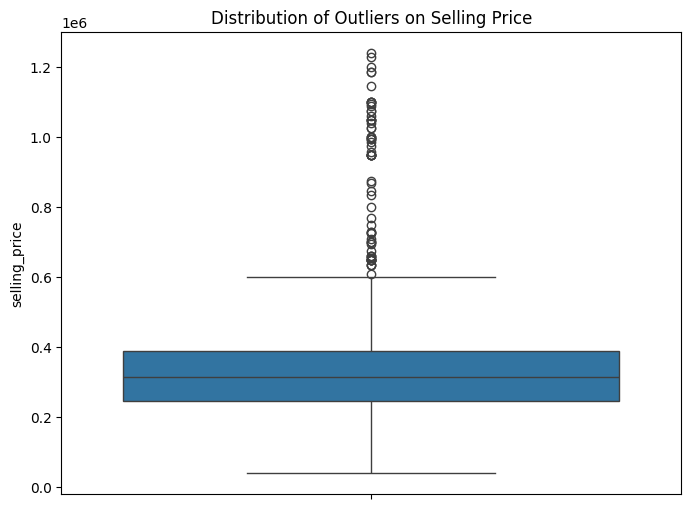

In [12]:
# Visualize outliers 'selling_price' with boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data['selling_price'])
plt.title('Distribution of Outliers on Selling Price')
plt.show()

The boxplot of the target variable _selling_price_ indicates the presence of outliers, which may also suggest that other numerical variables contain outliers.

# Exploratory Data Analysis (EDA)

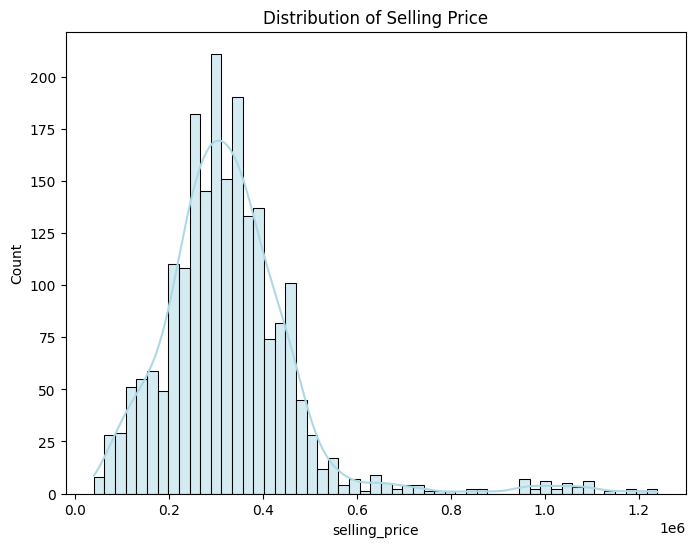

In [13]:
# Visualize distribution of Selling Price
plt.figure(figsize=(8,6))
sns.histplot(data['selling_price'], kde=True, color='lightblue')
plt.title('Distribution of Selling Price')
plt.show()

The distribution of selling_price is positively skewed (right-skewed), indicating that most observations are concentrated at lower values, with a few extreme high values pulling the mean to the right. Applying a log transformation can help reduce skewness and improve the normality of the target variable.

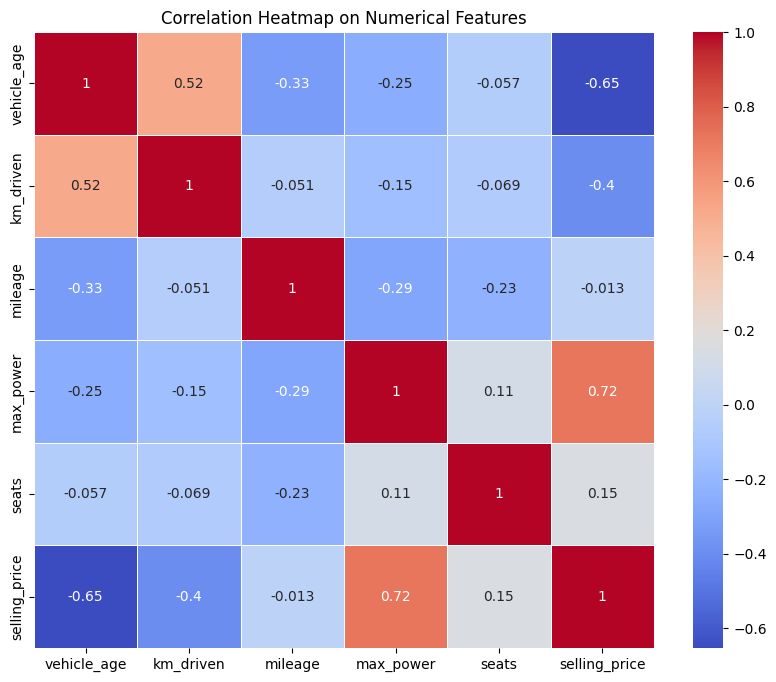

In [14]:
# Correlation on numerical columns
numeric_cols = data.select_dtypes(include='number').columns
cor = data[numeric_cols].corr(method='pearson')

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cor, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap on Numerical Features')
plt.show()

The Correlation heatmap shows there is positive relationship(0.72) between _max_power_ and _selling_price_. This implies, maximum engine power can influence the selling price of a car. But also _vehicle_age_ and _km_driven_ have positive relationship (0.52) meaning kilometer driven can influence vehicle age.

<h3> Is the selling price of a car influenced by its brand? </h3>

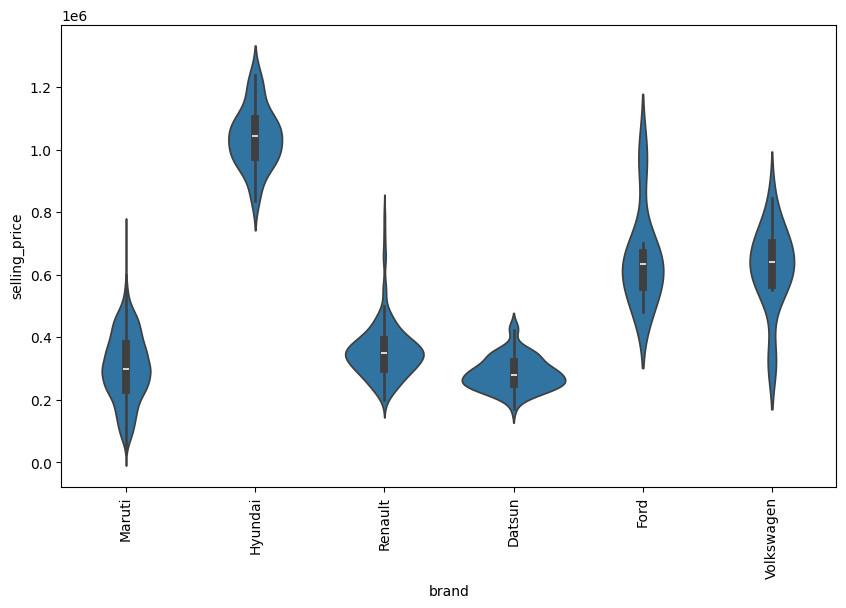

In [15]:
# Car brand by selling price

plt.figure(figsize=(10,6))
sns.violinplot(x='brand', y='selling_price', data=data)
plt.xticks(rotation=90)
plt.show()

The violin plot indicates substantial variation in selling price across brands. Hyundai exhibits the highest median selling price and the widest distribution, suggesting a broader price range and the presence of premium models. In contrast, Datsun shows the lowest median price with a narrow distribution, ndicating that most vehicles are priced in the lower range.

<h3>Is the selling price of a car influenced by its model?</h3>

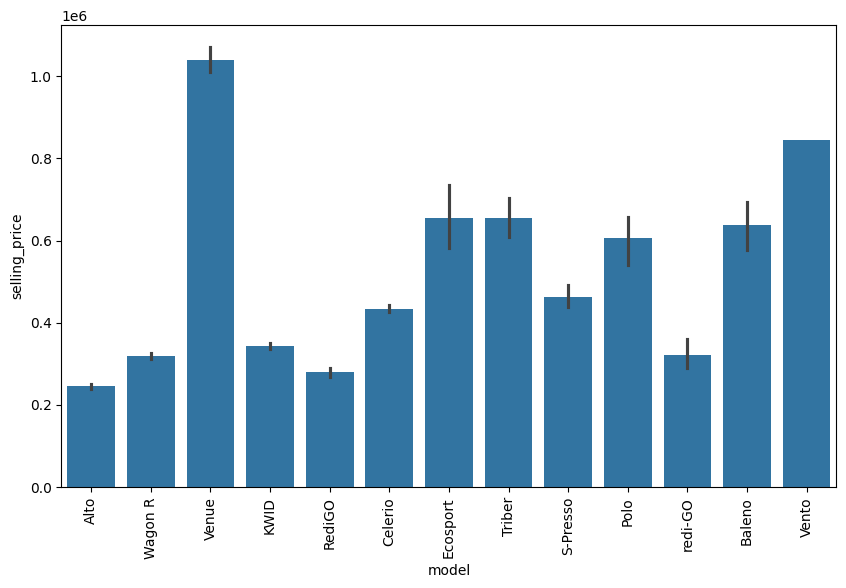

In [16]:
# Car model by selling price

plt.figure(figsize=(10,6))
sns.barplot(x='model', y='selling_price', data=data)
plt.xticks(rotation=90)
plt.show()

The bar plot illustrates significant variation in average selling prices across car models. The Hyundai Venue exhibits the highest mean selling price, positioning it in the premium segment. Models such as Ecosport, Triber, Polo, and Baleno fall within the upper-mid price range, while Alto, KWID, and RediGo are concentrated in the economy segment. The clear separation in price levels confirms that model is a strong determinant of selling price.

__Based on the exploratory data analysis conducted above, max_power, brand, and model appear to significantly influence the selling price of a car.__

### Handling Outliers

In [17]:
# Removing Outliers by using Interquantile Range (IQR)
numeric_df = data.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter rows without outliers (based only on numeric columns)
data = data[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [18]:
# Drop 'car_name' column to prevent overfitting
data = data.drop(columns=['car_name', 'mileage'], errors='ignore')

## Splitting Data

In [19]:
from sklearn.model_selection import train_test_split

X = data.drop('selling_price', axis=1) # independent variable
y = np.log1p(data['selling_price']) # apply log_transform on dependent variable to handle skewness

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Encoding Categorical Columns

In [20]:
# Target Encoding
# Note: model is the name of the column
global_mean = y_train.mean()

model_mean = pd.concat([X_train['model'], y_train], axis=1) \
               .groupby('model')['selling_price'] \
               .mean()

X_train['model_encoded'] = X_train['model'].map(model_mean)
X_test['model_encoded'] = X_test['model'].map(model_mean).fillna(global_mean)

X_train.drop('model', axis=1, inplace=True)
X_test.drop('model', axis=1, inplace=True)

# One-hot Encoding
X_train = pd.get_dummies(X_train, columns=['brand'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['brand'], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [21]:
# Save encoders and columns
joblib.dump(model_mean, "model_mean.pkl")
joblib.dump(global_mean, "global_mean.pkl")
joblib.dump(X_train.columns.tolist(), "car_columns.pkl")

['car_columns.pkl']

## Random Forest Regressor

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

rf = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=12,          # controls overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
print('Cross-Validation Scores:', cv_scores)
print('Mean CV Score:', np.mean(cv_scores))

Cross-Validation Scores: [-0.123417   -0.12123479 -0.11583757 -0.11771552 -0.11606792]
Mean CV Score: -0.11885455960243432


Five-fold cross-validation was applied to evaluate the model using Mean Absolute Error (MAE). The average cross-validation score obtained was −0.1189, corresponding to an MAE of approximately 0.119 in log-transformed price units. The small variation across the folds indicates that the model produces stable predictions and generalizes well to unseen data.

In [23]:
# Train
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [24]:
# Predict
pred_rf = rf.predict(X_test)

# Convert back from log scale
y_test_normal = np.expm1(y_test)
pred_normal = np.expm1(pred_rf)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_normal, pred_normal))
mae = mean_absolute_error(y_test_normal, pred_normal)
r2 = r2_score(y_test_normal, pred_normal)

# Print results
print("Random Forest Regressor")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

Random Forest Regressor
RMSE: 43041.86405428377
MAE: 33754.61077440329
R2 Score: 0.8006162249366393


## Decision Tree Regressor

In [25]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)

# Train
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=12, min_samples_leaf=2, random_state=42)

In [26]:
# Predict
pred_dt = dt.predict(X_test)

# Convert back from log scale
y_test_normal = np.expm1(y_test)
preds_normal = np.expm1(pred_dt)

# Metrics
dt_rmse = np.sqrt(mean_squared_error(y_test_normal, preds_normal))
dt_mae = mean_absolute_error(y_test_normal, preds_normal)
dt_r2 = r2_score(y_test_normal, preds_normal)

# Print results
print("Decision Tree Regressor")
print("RMSE:", dt_rmse)
print("MAE:", dt_mae)
print("R2 Score:", dt_r2)

Decision Tree Regressor
RMSE: 47939.889537329625
MAE: 37725.81446282075
R2 Score: 0.7526558008002451


## Linear Regression

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Train
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [29]:
# Predict
pred_lr = lr.predict(X_test_scaled)

# Convert back from log scale
y_test_lr = np.expm1(y_test)
preds_lr = np.expm1(pred_lr)

# Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test_lr, preds_lr))
lr_mae = mean_absolute_error(y_test_lr, preds_lr)
lr_r2 = r2_score(y_test_lr, preds_lr)

# Print results
print("Linear Regression")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

Linear Regression
RMSE: 45804.720883694106
MAE: 35862.817672334255
R2 Score: 0.774197807922851


# XGBoost

In [30]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=12,
    learning_rate=0.01,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
# Predict
pred_xgb = xgb.predict(X_test)

# Convert back from log scale
y_test_xgb = np.expm1(y_test)
y_pred_normal = np.expm1(pred_xgb)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, y_pred_normal))
xgb_mae = mean_absolute_error(y_test_xgb, y_pred_normal)
xgb_r2 = r2_score(y_test_xgb, y_pred_normal)

# Print results
print("XGBoost Regressor")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2 Score:", xgb_r2)

XGBoost Regressor
RMSE: 46045.414307478626
MAE: 37079.101756198324
R2 Score: 0.771818494272887


## Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV

# RandomForestRegressor
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.0s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.1s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.8s
[CV] END max_depth=8, min_samples_lea

In [33]:
best_rf = grid_search.best_estimator_

In [34]:
# make predictions
pred_rf_tuned = best_rf.predict(X_test)

y_test_tuned = np.expm1(y_test)
pred_tuned = np.expm1(pred_rf_tuned)

# model evaluation
tuned_rmse = np.sqrt(mean_squared_error(y_test_tuned, pred_tuned))
tuned_mae = mean_absolute_error(y_test_tuned, pred_tuned)
tuned_r2 = r2_score(y_test_tuned, pred_tuned)

print("Tuned Random Forest")
print("RMSE:", tuned_rmse)
print("MAE:", tuned_mae)
print("R2 Score:", tuned_r2)

Tuned Random Forest
RMSE: 41610.69858832789
MAE: 32382.40278325906
R2 Score: 0.8136550251094088


In [35]:
# saving randomforest model
joblib.dump(best_rf, "car_price_model.pkl")

['car_price_model.pkl']

### Results and Conclusion

This project developed machine learning models to predict used car selling prices. Initially, the dataset contained 2,119 samples and 9 features. After performing data cleaning, specifically by removing duplicate records, the dataset was reduced to 2,085 samples while maintaining the same number of features.

The target variable (selling_price) exhibited right skewness and contained several outliers. To address this issue, a logarithmic transformation was applied to the target variable in order to reduce skewness and stabilize variance. Additionally, outliers were treated across all numerical features, including the target variable, to improve model robustness and predictive performance.

<h4>Exploratory Data Analysis</h4>

__Correlation Analysis__ <br>
A correlation heatmap was used to examine the relationships among the variables in the dataset. The analysis revealed a moderate positive correlation between the features *vehicle_age* and *km_driven*. Highly correlated features may introduce redundancy and potentially contribute to model overfitting during training.

Furthermore, the correlation analysis identified *max_power* as one of the most influential variables affecting the selling price, exhibiting a strong positive correlation with the target variable. This suggests that vehicles with higher engine power tend to have higher resale values.

__Features affecting Selling Price__ <br>
Based on exploratory data analysis, three key features were identified as having a significant influence on the selling price of used cars:
- Maximum engine power (*max_power*)
- Car brand
- Car model

Other available features were retained to allow the machine learning models to automatically learn additional patterns in the data. However, the *car_name* column was removed because it contains information closely related to the car model, which could lead to data leakage or overfitting.

<h4>Encoding Categorical features</h4>

Two encoding techniques were used to transform categorical variables into numerical representations:

- __One-Hot Encoding__ was applied to the brand feature.
- __Target Encoding__ was applied to the model feature.

These encoding techniques allowed the models to effectively incorporate categorical information while maintaining computational efficiency.

<h4>Feature Scaling</h4>

Feature scaling was applied selectively based on the requirements of each machine learning algorithm.

Scaling was necessary for the Linear Regression model because it is sensitive to differences in feature magnitude. Without scaling, features with larger numerical ranges may dominate the model and negatively affect coefficient estimation.

In contrast, tree-based models such as Decision Tree, Random Forest, and XGBoost do not require feature scaling. These algorithms split data based on decision thresholds rather than feature magnitude or distance, making them invariant to the scale of input variables.

<h4>Modelling and Evaluation</h4>

The following machine learning models were implemented in this study:

- RandomForestRegressor
- DecisionTreeRegressor
- XGBRegressor
- LinearRegression

Model performance was evaluated using the following regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Since the dataset is relatively small, cross-validation was applied during model training to improve model reliability and ensure better generalization performance. Cross-validation allows the model to learn from multiple training subsets of the data, thereby reducing the risk of overfitting.

The experimental results indicate that tree-based ensemble models, particularly Random Forest and XGBoost, outperform Linear Regression. This is because ensemble tree models are capable of capturing nonlinear relationships and complex interactions between variables, which are common in real-world pricing data such as used car markets.

### Future Improvements
- __Increase Dataset Size__: more training data would help the model learn complex patterns and improve generalization.
- __Advanced Feature Engineering__: adding useful features such as Fuel type, Price depreciation rate, Brand reputation score, Engine capacity (eg. 1500cc, 2000cc etc) and Vehicle condition
- __Hyperparameter Tuning__: further optimization using _RandomizedSearchCV_ could imporove ensemble model performance but also faster than GridSearchCV.
- __Try Additional Algorithms__ such as LightGBM, CatBoost, Gradient Boosting Regressor since they perform better on tabular datasets.